# В этом ноутбуке показано формирование датасета кропов (для дальнейшего дообучения модели) из фото уличных вывесок и табличек и json-файла с аннотациями.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import kagglehub
import matplotlib.pyplot as plt
import os
import json
import cv2
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A

Требуемая структура файлов
```
all_data/
├── train/
│   ├── labels.csv
│   └── *.jpg
└── val/
    ├── labels.csv
    └── *.jpg
```

In [2]:
!pip install albumentations

In [3]:
ROOT = "/kaggle/input/datasets/evgeniyashpirnova/fullannotateddataset/full_annotated_data"

COCO_FILE = os.path.join(
    ROOT,
    "annotations",
    "instances_default.json"
)

IMAGE_DIR = os.path.join(
    ROOT,
    "images",
    "default"
)

# Train и val директории
os.makedirs("all_data/train", exist_ok=True)
os.makedirs("all_data/val", exist_ok=True)


In [4]:
# Загрузка COCO
with open(COCO_FILE, "r", encoding="utf-8") as f:
    coco = json.load(f)

# Словарь image_id -> file_name
image_map = {
    img["id"]: img["file_name"]
    for img in coco["images"]
}

samples = []
crop_id = 0

Формирование кропов из аннотаций и картинок

In [5]:
for ann in coco["annotations"]:

    text = ann.get("attributes", {}).get("text", "").strip()

    if not text:
        continue

    filename = image_map.get(ann["image_id"])

    if filename is None:
        continue

    image_path = os.path.join(
        IMAGE_DIR,
        filename
    )

    img = cv2.imread(image_path)

    if img is None:
        print("Cannot read:", image_path)
        continue

    x, y, w, h = ann["bbox"]

    x = max(0, int(x))
    y = max(0, int(y))
    w = int(w)
    h = int(h)

    if w < 20 or h < 10:
        continue

    crop = img[y:y+h, x:x+w]

    if crop.size == 0:
        continue

    crop_name = f"crop_{crop_id:06d}.jpg"

    temp_path = os.path.join(
        "/tmp",
        crop_name
    )

    cv2.imwrite(temp_path, crop)

    samples.append(
        (temp_path, crop_name, text)
    )

    crop_id += 1

print(f"Total crops: {len(samples)}")


Total crops: 2133


Аугментации: контраст, шум, размытие, перспектива

In [6]:
aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=5,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.2)
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
AUG_PER_IMAGE = 2   # сколько новых кропов на один оригинал

Разделение на train/test

In [8]:
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_rows = []
val_rows = []

Сохранение train и val датасетов

In [9]:
train_rows = []
val_rows = []

augmented_id = crop_id

for src, crop_name, text in train_samples:

    dst = os.path.join("all_data/train", crop_name)
    shutil.copy(src, dst)

    train_rows.append({
        "filename": crop_name,
        "words": text
    })

    img = cv2.imread(src)

    for i in range(AUG_PER_IMAGE):

        augmented = aug(image=img)["image"]

        aug_name = f"crop_{augmented_id:06d}.jpg"
        aug_path = os.path.join("all_data/train", aug_name)

        cv2.imwrite(aug_path, augmented)

        train_rows.append({
            "filename": aug_name,
            "words": text
        })

        augmented_id += 1

In [10]:
for src, crop_name, text in val_samples:

    dst = os.path.join("all_data/val", crop_name)
    shutil.copy(src, dst)

    val_rows.append({
        "filename": crop_name,
        "words": text
    })

In [11]:
print("Train images:", len(os.listdir("all_data/train")))
print("Val images:", len(os.listdir("all_data/val")))

Train images: 5757
Val images: 214


Формирование csv с labels 

In [12]:
# CSV
train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)

train_df.to_csv(
    "all_data/train/labels.csv",
    index=False,
    encoding="utf-8"
)

val_df.to_csv(
    "all_data/val/labels.csv",
    index=False,
    encoding="utf-8"
)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Train samples: 5757
Validation samples: 214


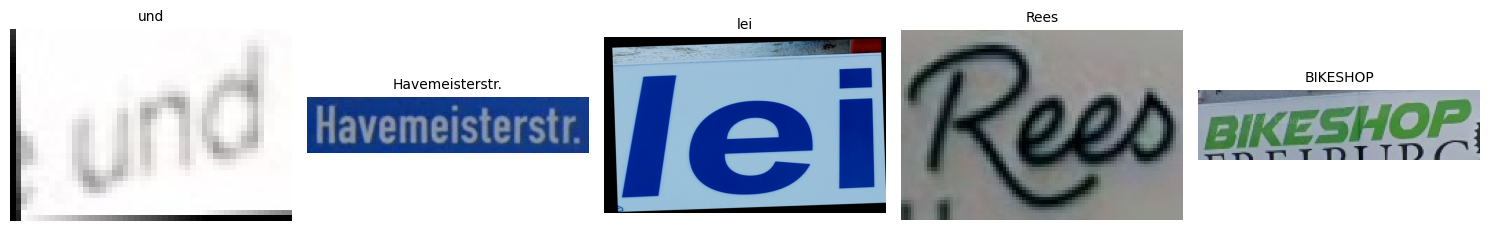

In [13]:
csv_path = "/kaggle/working/all_data/train/labels.csv"
img_dir = "/kaggle/working/all_data/train" 

df = pd.read_csv(csv_path, header=None, names=["image", "label"])

sample = df.sample(5, random_state=None)

plt.figure(figsize=(15, 10))

for i, row in enumerate(sample.itertuples()):
    img_path = os.path.join(img_dir, row.image)

    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray' if img.mode != 'RGB' else None)
    plt.title(row.label, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()